In [2]:
"""
=============================================================================
案例教程 19: 影像组学 (Radiomics) 特征提取 — CT 影像数据
=============================================================================
教学目标: 学会把"一张 CT 图像"变成"一行可建模的特征表", 完成从表格数据
         (教程 01-18 的癌症登记数据) 到影像数据 (本案例) 的迁移.

这是本综合案例的【第一步】, 也是与前面所有教程最大的不同:
  - 前面: 数据已经是干净的 CSV (一行 = 一个病人, 列 = 临床变量)
  - 这里: 原始数据是 100 张 CT 图像 (.dcm), 必须先"特征化"才能进入 ML 流程
  - 影像组学 (Radiomics) 就是这套"图像 → 高维定量特征"的标准化流程

影像组学标准流程 :
  ① 图像获取 → ② ROI 分割 → ③ 特征提取 → ④ 特征分析 → ⑤ 建模
  本脚本完成 ①~③, 下一脚本 (20) 完成 ④~⑤.

ROI 分割策略 (教学版):
  真实影像组学需手工/算法勾画肿瘤或器官 ROI. 本数据集无分割标注, 故采用
  "体部自动分割": 用 CT 的 HU 值阈值 (HU > -300) 取身体区域, 再保留最大连通
  域, 剔除背景空气与噪声. 这是一种常见且可复现的近似, 适合教学.
  → 教学要点: 让学生理解 HU 值、ROI、分割对特征的影响 (参见 lectures 知识树).

提取的特征类 (pyradiomics 标准):
  - firstorder  一阶统计 (均值/中位数/能量/熵/偏度/峰度 ...) 18 个
  - shape       形状特征 (2D: 周长/面积/紧致度 ...) 
  - glcm        灰度共生矩阵 (纹理: 对比度/相关性/同质性 ...)
  - glrlm       灰度游程矩阵
  - glszm       灰度大小区域矩阵
  - gldm        灰度依赖矩阵
  - ngtdm       灰度邻域差矩阵
  共 ~100+ 维 → 印证用户所说"影像组学特征会很多", 必须做特征选择 (见教程 20)

目标变量: Contrast (1=增强 CT, 0=平扫 CT), 50/50 平衡 → 教程 20 的二分类任务
  (增强 CT 含造影剂, 血管/脏器密度显著升高, 影像组学特征应能区分)

输出:
  - 特征表 → data/ct_data/radiomics_features.csv  (供教程 20 直接读取)
  - 图片   → img/19_*.png
  - 文本   → results/19_*.txt
=============================================================================
"""

'\n=============================================================================\n案例教程 19: 影像组学 (Radiomics) 特征提取 — CT 影像数据\n=============================================================================\n教学目标: 学会把"一张 CT 图像"变成"一行可建模的特征表", 完成从表格数据\n         (教程 01-18 的癌症登记数据) 到影像数据 (本案例) 的迁移.\n\n这是本综合案例的【第一步】, 也是与前面所有教程最大的不同:\n  - 前面: 数据已经是干净的 CSV (一行 = 一个病人, 列 = 临床变量)\n  - 这里: 原始数据是 100 张 CT 图像 (.dcm), 必须先"特征化"才能进入 ML 流程\n  - 影像组学 (Radiomics) 就是这套"图像 → 高维定量特征"的标准化流程\n\n影像组学标准流程 :\n  ① 图像获取 → ② ROI 分割 → ③ 特征提取 → ④ 特征分析 → ⑤ 建模\n  本脚本完成 ①~③, 下一脚本 (20) 完成 ④~⑤.\n\nROI 分割策略 (教学版):\n  真实影像组学需手工/算法勾画肿瘤或器官 ROI. 本数据集无分割标注, 故采用\n  "体部自动分割": 用 CT 的 HU 值阈值 (HU > -300) 取身体区域, 再保留最大连通\n  域, 剔除背景空气与噪声. 这是一种常见且可复现的近似, 适合教学.\n  → 教学要点: 让学生理解 HU 值、ROI、分割对特征的影响 (参见 lectures 知识树).\n\n提取的特征类 (pyradiomics 标准):\n  - firstorder  一阶统计 (均值/中位数/能量/熵/偏度/峰度 ...) 18 个\n  - shape       形状特征 (2D: 周长/面积/紧致度 ...) \n  - glcm        灰度共生矩阵 (纹理: 对比度/相关性/同质性 ...)\n  - glrlm       灰度游程矩阵\n  - glszm       灰度大小区域矩阵\n  - gldm    

In [1]:
import os
import sys
import time
import warnings
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
import SimpleITK as sitk
from radiomics import featureextractor

warnings.filterwarnings('ignore')
# 抑制 pyradiomics 冗余日志 (默认会打印每步处理信息, 干扰教学输出)
logging.getLogger('radiomics').setLevel(logging.ERROR)

In [3]:
BASE_DIR = ".."
DATA_DIR = os.path.join(BASE_DIR, "data", "ct_data")
DICOM_DIR = os.path.join(DATA_DIR, "dicom_dir")
OVERVIEW_CSV = os.path.join(DATA_DIR, "overview.csv")
FEATURES_CSV = os.path.join(DATA_DIR, "radiomics_features.csv")  # 本脚本输出
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_STATE = 42
# 体部分割阈值 (HU). -300 ~ -100 通常区分软组织与肺/脂肪; 这里取 -300 保留身体.
BODY_HU_THRESHOLD = -300

In [4]:
print("\n[0] 读取数据清单 overview.csv ...")
overview = pd.read_csv(OVERVIEW_CSV)
# 目标变量: Contrast (True/False) → 1/0
overview['Contrast'] = overview['Contrast'].astype(int)
print(f"    样本数: {len(overview)}")
print(f"    增强 (Contrast=1): {(overview['Contrast'] == 1).sum()}  "
      f"| 平扫 (Contrast=0): {(overview['Contrast'] == 0).sum()}")
print(f"    年龄范围: {overview['Age'].min()} ~ {overview['Age'].max()} "
      f"(中位数 {int(overview['Age'].median())})")


[0] 读取数据清单 overview.csv ...
    样本数: 100
    增强 (Contrast=1): 50  | 平扫 (Contrast=0): 50
    年龄范围: 39 ~ 83 (中位数 70)


In [5]:

# ============================================================================
# 1. 工具函数: DICOM → HU 图像 → 体部 ROI mask
# ============================================================================
def dicom_to_hu(dcm_path):
    """读取 DICOM 并转成 HU (Hounsfield Unit) 矩阵.

    HU 是 CT 的标准化密度刻度:
      水 = 0 HU, 空气 = -1000 HU, 骨 = +400~+1000 HU, 软组织 ≈ +40~+80 HU
    DICOM 像素值通过 RescaleSlope/RescaleIntercept 映射到 HU:
      HU = pixel * slope + intercept
    """
    ds = pydicom.dcmread(dcm_path)
    arr = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, 'RescaleSlope', 1))
    intercept = float(getattr(ds, 'RescaleIntercept', 0))
    hu = arr * slope + intercept
    return hu, ds


def body_mask(hu, hu_threshold=BODY_HU_THRESHOLD):
    """阈值法 + 最大连通域提取体部 ROI mask (二值, 1=体部).

    步骤:
      1. HU > threshold → 候选体素 (剔除空气/背景)
      2. 连通域分析 → 保留最大连通域 (剔除零散噪声/床板)
    返回 SimpleITK Image (mask) 与原始图像 SimpleITK Image.
    """
    # 原始图像 (float32)
    img_sitk = sitk.GetImageFromArray(hu.astype(np.float32))
    # 二值 mask
    mask_arr = (hu > hu_threshold).astype(np.uint8)
    mask_sitk = sitk.GetImageFromArray(mask_arr)
    # 连通域 + 取最大
    cc = sitk.ConnectedComponent(mask_sitk)
    cc = sitk.RelabelComponent(cc, sortByObjectSize=True)
    largest = sitk.BinaryThreshold(cc, lowerThreshold=1, upperThreshold=1,
                                   insideValue=1, outsideValue=0)
    return img_sitk, largest


In [6]:
# ============================================================================
# 2. 配置 pyradiomics 特征提取器
# ============================================================================
print("\n[1] 配置 pyradiomics 特征提取器 ...")
extractor = featureextractor.RadiomicsFeatureExtractor()
# 单层 CT (2D), 必须开启 force2D, 否则部分 3D 纹理特征会失败
extractor.settings['force2D'] = True
extractor.settings['force2Ddimension'] = 0
extractor.settings['label'] = 1
# 关闭小波/LoG 滤波 (会产生 8x/多组特征, 教学版只保留 original, 避免特征爆炸)
extractor.disableAllImageTypes()
extractor.enableImageTypes(Original={})

# 启用全部标准特征类
extractor.enableFeatureClassByName('firstorder')
extractor.enableFeatureClassByName('shape')
extractor.enableFeatureClassByName('glcm')
extractor.enableFeatureClassByName('glrlm')
extractor.enableFeatureClassByName('glszm')
extractor.enableFeatureClassByName('gldm')
extractor.enableFeatureClassByName('ngtdm')

# 预先跑一个样本, 探明特征列名与数量 (教学要点: 让学生看到"特征到底有多少")
print("\n[2] 预跑 1 个样本, 探明特征结构 ...")
probe_path = os.path.join(DICOM_DIR, overview.loc[0, 'dicom_name'])
hu0, _ = dicom_to_hu(probe_path)
img0, mask0 = body_mask(hu0)
res0 = extractor.execute(img0, mask0)
FEATURE_NAMES = [k for k in res0.keys() if not k.startswith('diagnostics')]
print(f"    单样本提取特征数: {len(FEATURE_NAMES)}")
# 按特征类统计
class_counts = {}
for name in FEATURE_NAMES:
    cls = name.split('_')[1]  # original_<class>_<feat>
    class_counts[cls] = class_counts.get(cls, 0) + 1
print(f"    各特征类数量: {class_counts}")


[1] 配置 pyradiomics 特征提取器 ...

[2] 预跑 1 个样本, 探明特征结构 ...
    单样本提取特征数: 93
    各特征类数量: {'firstorder': 18, 'glcm': 24, 'gldm': 14, 'glrlm': 16, 'glszm': 16, 'ngtdm': 5}


In [7]:
# ============================================================================
# 3. 批量提取全部 100 个样本
# ============================================================================
print("\n[3] 批量提取全部样本特征 ...")
t0 = time.time()
rows = []
fail_ids = []
for i, row in overview.iterrows():
    dcm_path = os.path.join(DICOM_DIR, row['dicom_name'])
    try:
        hu, _ = dicom_to_hu(dcm_path)
        img_sitk, mask_sitk = body_mask(hu)
        result = extractor.execute(img_sitk, mask_sitk)
        feat_row = {'id': int(row['id']), 'Age': int(row['Age']),
                    'Contrast': int(row['Contrast'])}
        for name in FEATURE_NAMES:
            feat_row[name] = float(result[name])
        rows.append(feat_row)
    except Exception as e:
        fail_ids.append((int(row['id']), str(e)[:80]))

    if (i + 1) % 20 == 0 or i == len(overview) - 1:
        print(f"    进度 {i + 1}/{len(overview)}  "
              f"({(i + 1) / len(overview) * 100:.0f}%)  "
              f"耗时 {time.time() - t0:.1f}s")

features_df = pd.DataFrame(rows)
elapsed = time.time() - t0
print(f"\n    完成! 共 {len(features_df)}/{len(overview)} 个样本成功, 耗时 {elapsed:.1f}s")
if fail_ids:
    print(f"    失败 {len(fail_ids)} 个: {fail_ids[:5]}")

# 保存特征表 (这是教程 20 的输入)
features_df.to_csv(FEATURES_CSV, index=False)
print(f"    特征表已保存 → {FEATURES_CSV}")
print(f"    形状: {features_df.shape}  "
      f"(样本 × [id + Age + Contrast + {len(FEATURE_NAMES)} 影像组学特征])")


[3] 批量提取全部样本特征 ...
    进度 20/100  (20%)  耗时 2.6s
    进度 40/100  (40%)  耗时 5.3s
    进度 60/100  (60%)  耗时 7.7s
    进度 80/100  (80%)  耗时 10.2s
    进度 100/100  (100%)  耗时 12.5s

    完成! 共 100/100 个样本成功, 耗时 12.5s
    特征表已保存 → ../data/ct_data/radiomics_features.csv
    形状: (100, 96)  (样本 × [id + Age + Contrast + 93 影像组学特征])


In [8]:

# ============================================================================
# 4. 特征质量快速核查 — 类比教程 01 的数据概况
# ============================================================================
print("\n" + "=" * 70)
print("内容: 特征质量核查 (类比教程 01 EDA)")
print("=" * 70)

feat_cols = FEATURE_NAMES
X = features_df[feat_cols]
print(f"\n  ▶ 影像组学特征数: {len(feat_cols)}")
print(f"  ▶ 含缺失值特征数: {X.isnull().sum().sum()}  (应为 0, 否则需插补, 见教程 03)")
print(f"  ▶ 含 inf 特征数:   {np.isinf(X.values).sum()}  (纹理特征在均匀区可能 inf, 需处理)")

# 方差为 0 的特征 (无区分度, 应剔除 — 教程 05 第一层筛选)
zero_var = [c for c in feat_cols if X[c].std() == 0]
print(f"  ▶ 零方差特征数:    {len(zero_var)}  (将在教程 20 中剔除)")

# 特征量级跨度 (说明为何必须标准化 — 教程 03/04)
ranges = X.max() - X.min()
print(f"  ▶ 特征量级跨度:    {ranges.min():.2f} ~ {ranges.max():.2f}  (跨度极大 → 必须标准化)")


内容: 特征质量核查 (类比教程 01 EDA)

  ▶ 影像组学特征数: 93
  ▶ 含缺失值特征数: 0  (应为 0, 否则需插补, 见教程 03)
  ▶ 含 inf 特征数:   0  (纹理特征在均匀区可能 inf, 需处理)
  ▶ 零方差特征数:    0  (将在教程 20 中剔除)
  ▶ 特征量级跨度:    0.00 ~ 6510809895.00  (跨度极大 → 必须标准化)



内容: 可视化
  [图] 19_ct_hu_roi.png → CT/HU/ROI 三联图已保存


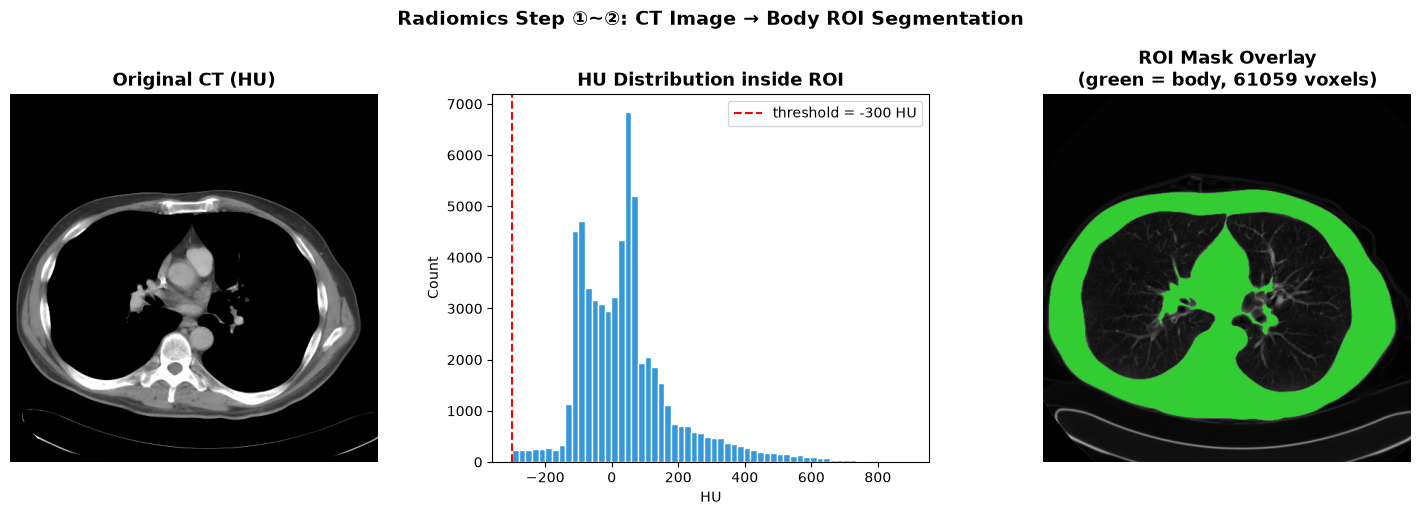

In [9]:

# ============================================================================
# 5. 可视化
# ============================================================================
print("\n" + "=" * 70)
print("内容: 可视化")
print("=" * 70)

# --- 图1: CT + HU + ROI mask 三联图 (让学生直观理解"图像→ROI") ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
hu_disp = hu0
mask_disp = sitk.GetArrayFromImage(mask0)

axes[0].imshow(hu_disp, cmap='gray', vmin=-200, vmax=300)
axes[0].set_title('Original CT (HU)', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].hist(hu_disp[mask_disp == 1].ravel(), bins=60, color='#3498db',
             edgecolor='white')
axes[1].axvline(BODY_HU_THRESHOLD, color='red', ls='--', lw=1.5,
                label=f'threshold = {BODY_HU_THRESHOLD} HU')
axes[1].set_title('HU Distribution inside ROI', fontsize=13, fontweight='bold')
axes[1].set_xlabel('HU'); axes[1].set_ylabel('Count'); axes[1].legend()

overlay = np.dstack([hu_disp, hu_disp, hu_disp])
overlay = (overlay - overlay.min()) / (overlay.max() - overlay.min() + 1e-9)
overlay[mask_disp == 1] = [0.2, 0.8, 0.2]  # 绿色高亮 ROI
axes[2].imshow(overlay)
axes[2].set_title(f'ROI Mask Overlay\n(green = body, '
                  f'{mask_disp.sum()} voxels)', fontsize=13, fontweight='bold')
axes[2].axis('off')

plt.suptitle('Radiomics Step ①~②: CT Image → Body ROI Segmentation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "19_ct_hu_roi.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 19_ct_hu_roi.png → CT/HU/ROI 三联图已保存")

  [图] 19_feature_class_and_label.png → 特征类数量+标签分布已保存


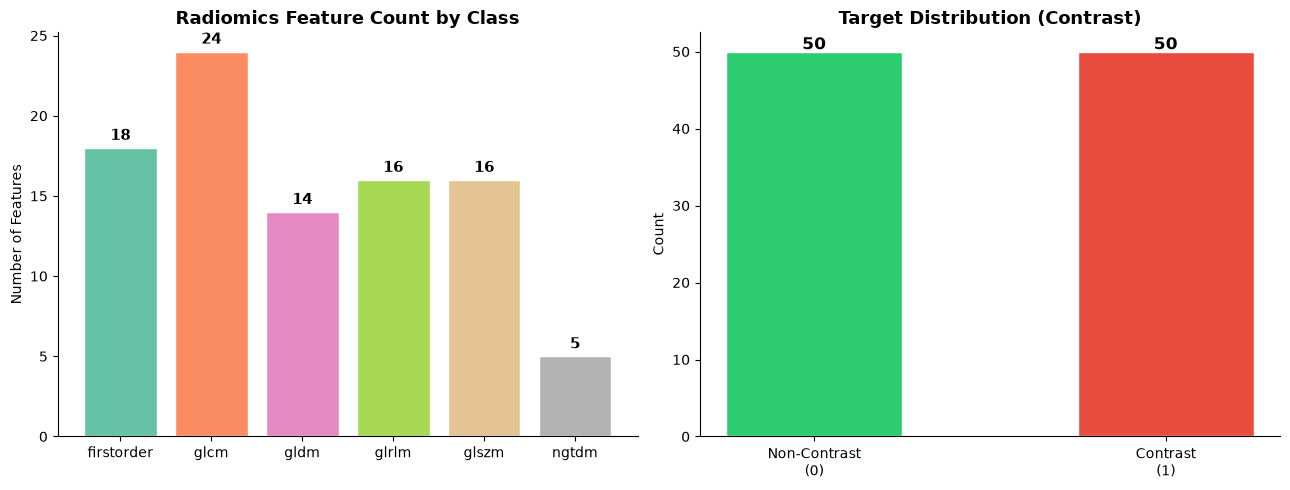

In [10]:
# --- 图2: 各特征类数量 + 标签分布 ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
classes = list(class_counts.keys())
counts = list(class_counts.values())
colors_cls = plt.cm.Set2(np.linspace(0, 1, len(classes)))
bars = axes[0].bar(classes, counts, color=colors_cls, edgecolor='white')
for bar, c in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(c), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Radiomics Feature Count by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Features')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

ct_counts = features_df['Contrast'].value_counts().sort_index()
axes[1].bar(['Non-Contrast\n(0)', 'Contrast\n(1)'], ct_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
for i, v in enumerate(ct_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Target Distribution (Contrast)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "19_feature_class_and_label.png"),
            dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 19_feature_class_and_label.png → 特征类数量+标签分布已保存")

  [图] 19_feature_preview_by_class.png → 关键特征两组对比预览已保存


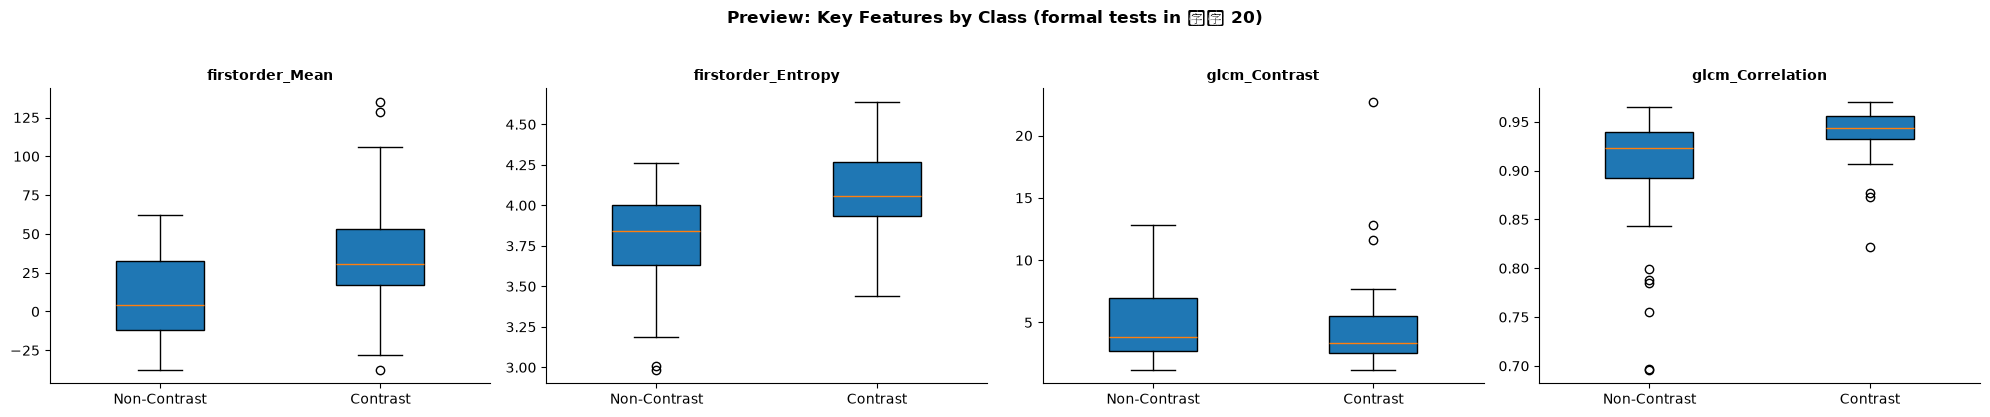

In [12]:
# --- 图3: Top 重要特征在两类间的分布预览 (直觉: 哪些特征可能有用) ---
# 用 firstorder_Mean (ROI 内平均 HU) 和 GLCM_Contrast 做两组对比
preview_feats = [c for c in ['original_firstorder_Mean',
                             'original_firstorder_Entropy',
                             'original_glcm_Contrast',
                             'original_glcm_Correlation']
                 if c in feat_cols]
if preview_feats:
    fig, axes = plt.subplots(1, len(preview_feats), figsize=(5 * len(preview_feats), 4))
    if len(preview_feats) == 1:
        axes = [axes]
    for ax, feat in zip(axes, preview_feats):
        g0 = features_df.loc[features_df['Contrast'] == 0, feat].dropna()
        g1 = features_df.loc[features_df['Contrast'] == 1, feat].dropna()
        ax.boxplot([g0, g1], tick_labels=['Non-Contrast', 'Contrast'],
                   patch_artist=True, widths=0.4)
        ax.set_title(feat.replace('original_', ''), fontsize=10, fontweight='bold')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.suptitle('Preview: Key Features by Class (formal tests in 教程 20)',
                 fontsize=12, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(os.path.join(IMG_DIR, "19_feature_preview_by_class.png"),
                dpi=150, bbox_inches='tight')
    # plt.close()
    print("  [图] 19_feature_preview_by_class.png → 关键特征两组对比预览已保存")

 
